→ Loading penguins dataset from seaborn…
✔️  Loaded 342 non-null values for 'body_mass_g'
✔️  Series length T=342; normalized mean=4201.75, std=800.78
✔️  Testing with N=2 series, each of shape (T=342, D=1)
→ Window size W=20
✔️  Total windows M=646 (StatDataset length = 646)

--- WindowDataset item 0 ---
 window.shape: torch.Size([20, 1])
 start_idx: 0
 series_len: 342
 window[0:3]: [ 0.01171696  0.12888658 -1.1599792 ]
--- StatDataset item 0 ---
 mean.shape: torch.Size([1])
 variance.shape: torch.Size([1])
 start_idx: 0
 series_len: 342
 mean: [3745.]
 variance: [182100.]

--- WindowDataset item 1 ---
 window.shape: torch.Size([20, 1])
 start_idx: 1
 series_len: 342
 window[0:3]: [ 0.14606401 -1.1392994  -0.6718945 ]
--- StatDataset item 1 ---
 mean.shape: torch.Size([1])
 variance.shape: torch.Size([1])
 start_idx: 1
 series_len: 342
 mean: [3737.5]
 variance: [183093.75]

--- WindowDataset item 2 ---
 window.shape: torch.Size([20, 1])
 start_idx: 2
 series_len: 342
 window[0:3]: [-

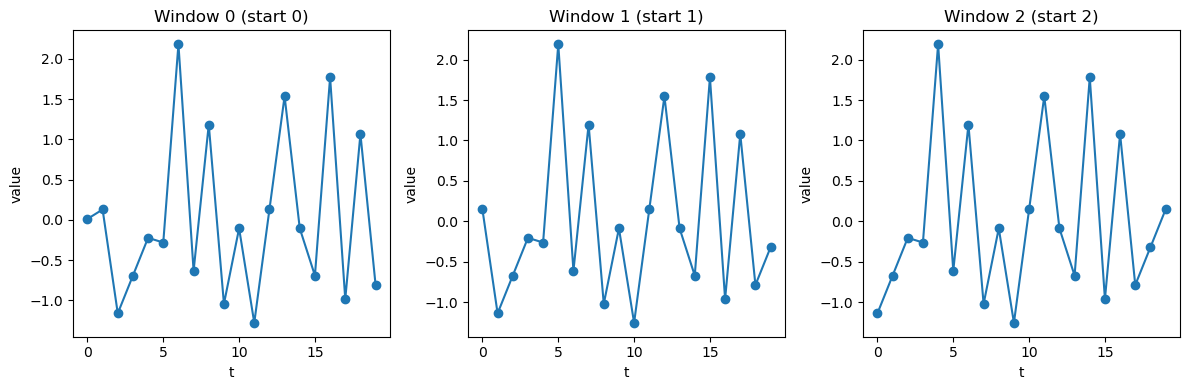

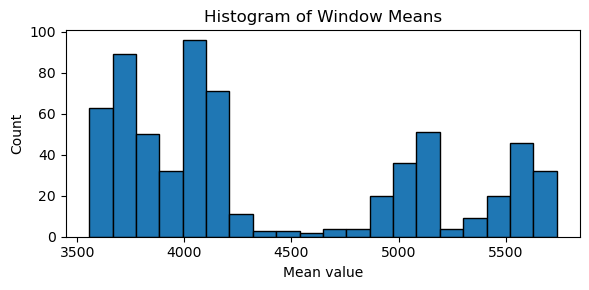

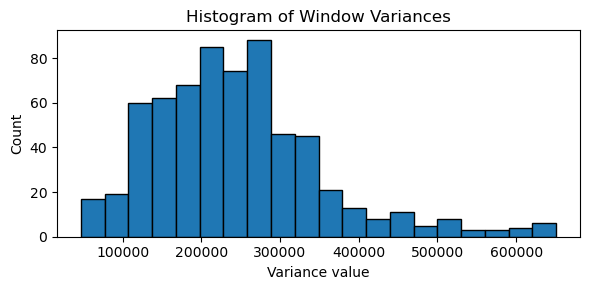

In [5]:
# Test script for SeriesWindowDataset and StatDataset

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from window_dataset import WindowDataset
from stat_dataset import StatDataset

# 1) Load penguins dataset and extract feature
print("→ Loading penguins dataset from seaborn…")
df = sns.load_dataset("penguins")
FEATURE = "body_mass_g"
raw = df[FEATURE].dropna().to_numpy(dtype=np.float32)
print(f"✔️  Loaded {len(raw)} non-null values for {FEATURE!r}")

series = raw
T = len(series)
print(f"✔️  Series length T={T}; normalized mean={series.mean():.2f}, std={series.std():.2f}")
D = 1
series_np = series.reshape(T, D)

# 3) Create a second synthetic series and bundle inputs
series_np2 = series_np * 1.1 + 0.1
inputs = [series_np, series_np2]
N = len(inputs)
print(f"✔️  Testing with N={N} series, each of shape (T={T}, D={D})")

# 4) Instantiate the datasets
window_size = 20
print(f"→ Window size W={window_size}")
window_ds = WindowDataset(inputs, window_size)
stat_ds   = StatDataset(inputs, window_size)
M = len(window_ds)
print(f"✔️  Total windows M={M} (StatDataset length = {len(stat_ds)})")

# 5) Inspect the first 3 items from each dataset
for idx in range(3):
    w_item = window_ds[idx]
    s_item = stat_ds[idx]
    print(f"\n--- WindowDataset item {idx} ---")
    print(" window.shape:", w_item['window'].shape)
    print(" start_idx:",   w_item['start_idx'].item())
    print(" series_len:",  w_item['series_len'].item())
    print(" window[0:3]:",  w_item['window'][:3].numpy().flatten())
    print(f"--- StatDataset item {idx} ---")
    print(" mean.shape:",     s_item['mean'].shape)
    print(" variance.shape:", s_item['variance'].shape)
    print(" start_idx:",      s_item['start_idx'].item())
    print(" series_len:",     s_item['series_len'].item())
    print(" mean:",           s_item['mean'].numpy())
    print(" variance:",       s_item['variance'].numpy())

# 6) Plot the first 3 windows
plt.figure(figsize=(12, 4))
for i in range(3):
    win = window_ds[i]['window'].numpy().flatten()
    start = window_ds[i]['start_idx'].item()
    plt.subplot(1, 3, i+1)
    plt.plot(win, marker='o')
    plt.title(f"Window {i} (start {start})")
    plt.xlabel("t"); plt.ylabel("value")
plt.tight_layout()
plt.show()

# 7) Histogram of all window means
means = np.array([item['mean'].item() for item in stat_ds])
plt.figure(figsize=(6, 3))
plt.hist(means, bins=20, edgecolor='black')
plt.title("Histogram of Window Means")
plt.xlabel("Mean value"); plt.ylabel("Count")
plt.tight_layout()
plt.show()

# 8) Histogram of all window variances
vars_ = np.array([item['variance'].item() for item in stat_ds])
plt.figure(figsize=(6, 3))
plt.hist(vars_, bins=20, edgecolor='black')
plt.title("Histogram of Window Variances")
plt.xlabel("Variance value"); plt.ylabel("Count")
plt.tight_layout()
plt.show()


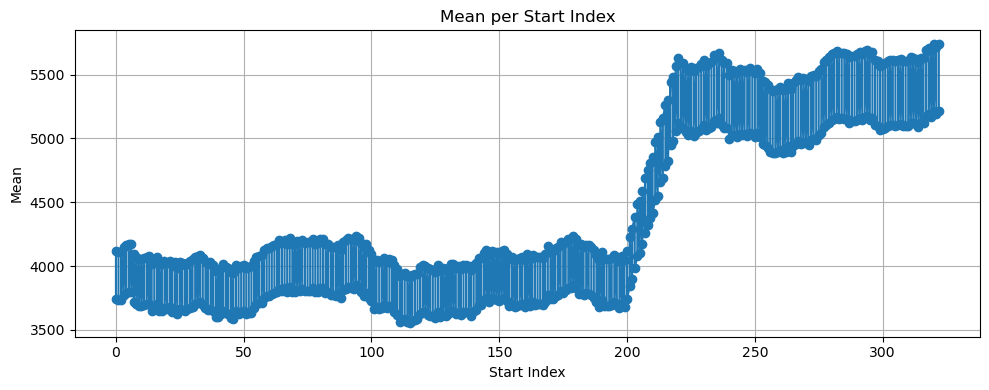

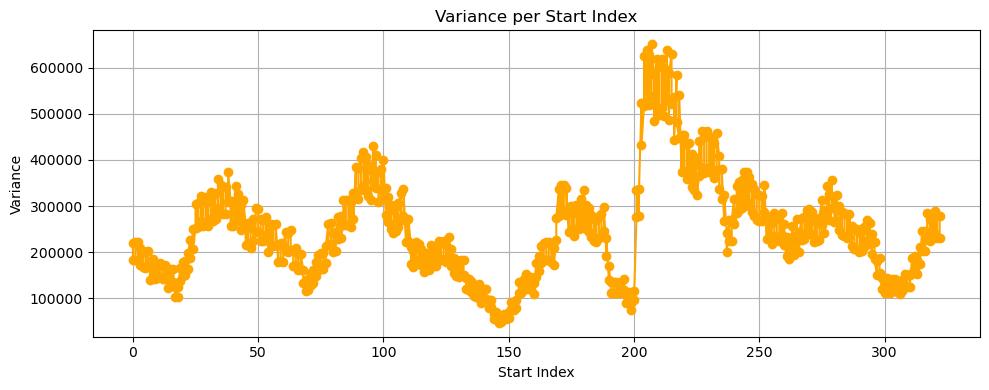

In [6]:
# 9) Mean and variance per start_idx
start_indices = []
means = []
variances = []

for item in stat_ds:
    start_indices.append(item['start_idx'].item())
    means.append(item['mean'].item())
    variances.append(item['variance'].item())

# Sort by start index to ensure ordered plots
sorted_indices = np.argsort(start_indices)
start_indices = np.array(start_indices)[sorted_indices]
means = np.array(means)[sorted_indices]
variances = np.array(variances)[sorted_indices]

# Plot mean per start_idx
plt.figure(figsize=(10, 4))
plt.plot(start_indices, means, marker='o', linestyle='-')
plt.title("Mean per Start Index")
plt.xlabel("Start Index")
plt.ylabel("Mean")
plt.grid(True)
plt.tight_layout()
plt.show()

# Plot variance per start_idx
plt.figure(figsize=(10, 4))
plt.plot(start_indices, variances, marker='o', linestyle='-', color='orange')
plt.title("Variance per Start Index")
plt.xlabel("Start Index")
plt.ylabel("Variance")
plt.grid(True)
plt.tight_layout()
plt.show()


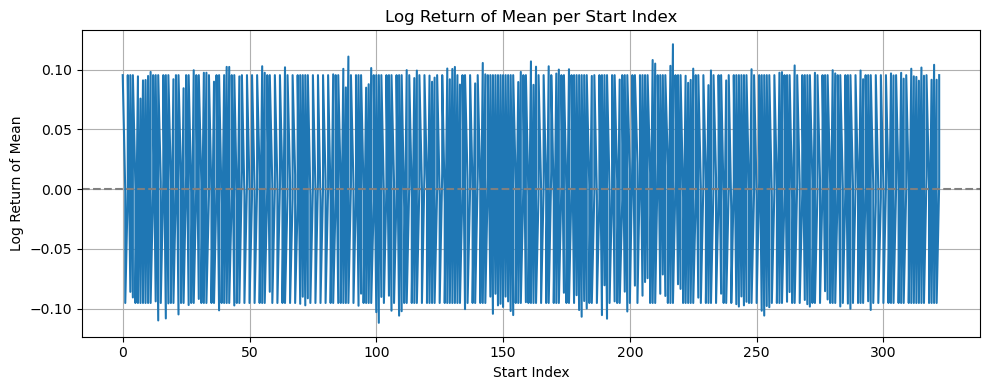

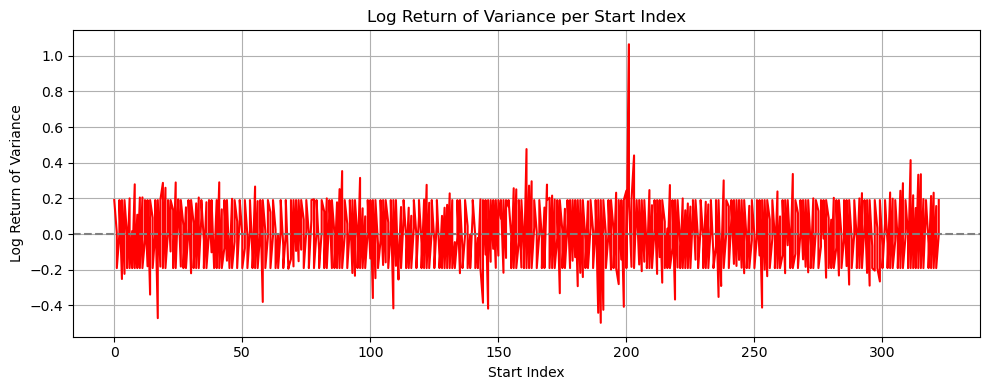

In [9]:
# 10) Compute log returns of mean and variance
mean_returns = np.log(means[1:] / means[:-1])
var_returns = np.log(variances[1:] / variances[:-1])

# Start indices for returns are shifted by 1
return_indices = start_indices[1:]

# Plot log return of mean
plt.figure(figsize=(10, 4))
plt.plot(return_indices, mean_returns, marker='', linestyle='-')
plt.title("Log Return of Mean per Start Index")
plt.xlabel("Start Index")
plt.ylabel("Log Return of Mean")
plt.axhline(0, color='gray', linestyle='--')
plt.grid(True)
plt.tight_layout()
plt.show()

# Plot log return of variance
plt.figure(figsize=(10, 4))
plt.plot(return_indices, var_returns, marker='', linestyle='-', color='red')
plt.title("Log Return of Variance per Start Index")
plt.xlabel("Start Index")
plt.ylabel("Log Return of Variance")
plt.axhline(0, color='gray', linestyle='--')
plt.grid(True)
plt.tight_layout()
plt.show()
